# CKD mixtures with random overlap, resorting and rebinning

This tutorial combines two species with `mix_ckd_rorr`, computes an
emission spectrum, and checks abundance and temperature derivatives.
It runs offline using small **synthetic CKD tables**. Species A and B
are invented absorbers; their spectra and errors are not predictions
for real molecules.

## Why mixing needs an overlap assumption

In line-by-line calculations, optical depths add at the same
wavenumber. CKD instead sorts absorption strengths within each band.
Its cumulative probability coordinate, $g$, no longer identifies a
wavenumber. Adding independently tabulated species at the same $g$
assumes that their strongest and weakest absorption coincide.

**Random overlap** assumes independent absorption strengths within
each band. For two species, all pairs have

$$\tau_{ij} = \tau_{A,i} + \tau_{B,j},\qquad p_{ij}=w_iw_j.$$

No random numbers are used. Keeping every combination would require
$N_g^S$ points for $S$ species. **RORR** sorts each pairwise mixture
by optical depth and averages it back to $N_g$ points before adding
the next species. See [Amundsen et al. (2017), Section 3.2](https://arxiv.org/abs/1610.01389)
for the overlap methods and their assumptions.

The output points are weighted means over cumulative probability
intervals whose widths are the original `weights`. They are not
samples of a new distribution evaluated at the original
Gauss-Legendre nodes. Pass the same weights to radiative transfer.
This construction preserves mean optical depth, but not generally
transmission, which depends on $\exp(-\tau)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from exojax.opacity import OpaCKD
from exojax.opacity.ckd.contracts import CKDTableInfo
from exojax.opacity.ckd.core import gauss_legendre_grid
from exojax.opacity.ckd.mixing import (
    mix_ckd_rorr,
    validate_ckd_mixture_tables,
)
from exojax.rt import ArtEmisPure
from exojax.rt.layeropacity import layer_optical_depth_ckd

jax.config.update("jax_enable_x64", True)

## Prepare compatible tables

All species must have the same number of points, normalized positive
weights, band edges, and ordered band centers. Their temperature and
pressure grids can differ: each table is interpolated independently.
Run `validate_ckd_mixture_tables` once during setup, outside `jax.jit`.

For this offline example only, we populate `OpaCKD.load_only()` with
explicit `CKDTableInfo` objects. In applications, load saved molecular
tables with `OpaCKD.from_saved_tables` as shown at the end.

In [2]:
ng = 8
ggrid, weights = gauss_legendre_grid(ng)
edges = jnp.linspace(800.0, 2000.0, 13)  # Wavenumber, cm^-1
band_edges = jnp.stack((edges[:-1], edges[1:]), axis=1)
nu_bands = jnp.mean(band_edges, axis=1)


def synthetic_table(species):
    # These smooth distributions have no associated molecular line list.
    tgrid = jnp.array([450.0, 1450.0] if species == 0
                      else [400.0, 850.0, 1500.0])
    pgrid = jnp.array([1.e-4, 0.02, 30.0] if species == 0
                      else [1.e-4, 30.0])
    center = 1100.0 if species == 0 else 1650.0
    band_shape = 1.6 * jnp.exp(-((nu_bands - center) / 220.0) ** 2)
    log_k = (
        -56.6 + band_shape[None, None, None, :]
        + (2.4 + 0.7 * species) * (2.0 * ggrid[None, None, :, None] - 1.0)
        + (0.25 - 0.6 * species) * (tgrid[:, None, None, None] / 1000.0 - 1.0)
        + (0.12 + 0.04 * species) * jnp.log(pgrid[None, :, None, None])
    )
    opa = OpaCKD.load_only()
    opa.ckd_info = CKDTableInfo(
        log_kggrid=log_k, ggrid=ggrid, weights=weights,
        T_grid=tgrid, P_grid=pgrid,
        nu_bands=nu_bands, band_edges=band_edges,
    )
    opa.Ng = ng
    opa.nu_bands = nu_bands
    opa.band_edges = band_edges
    opa.ready = True
    return opa


opas = [synthetic_table(0), synthetic_table(1)]  # Keep this order fixed.
validate_ckd_mixture_tables(opas)
for label, opa in zip(("A", "B"), opas):
    print(f"Species {label}: (NT, NP, Ng, Nband) = {opa.ckd_info.log_kggrid.shape}")

Species A: (NT, NP, Ng, Nband) = (2, 3, 8, 12)
Species B: (NT, NP, Ng, Nband) = (3, 2, 8, 12)


## Convert each species to optical depth, then mix

`mix_ckd_rorr` accepts optical depths of shape
`(Nspecies, Nlayer, Ng, Nband)` and returns `(Nlayer, Ng, Nband)`.
Inputs must be finite and nonnegative. Ordinary CKD tables are sorted
along the `Ng` axis for each species, layer, and band.

For a volume mixing ratio (VMR), `layer_optical_depth_ckd` requires the
**mean molecular weight of the atmosphere**. For a mass mixing ratio
(MMR), it requires the **molecular mass of the absorber**. Mixing
optical depths keeps this conversion separate from the RORR step.

Here the background gas has mean molecular weight 2.3, and the
invented absorbers have molecular masses 18 and 44. Their VMRs
determine the background fraction and the atmospheric mean molecular
weight. The chosen VMRs sum to less than one.

In [3]:
art = ArtEmisPure(
    pressure_top=0.002, pressure_btm=3.0, nlayer=8,
    nu_grid=nu_bands, nstream=4,
)
base_temperature = jnp.linspace(650.0, 1250.0, art.nlayer)
molecular_masses = jnp.array([18.0, 44.0])
background_mmw = 2.3
gravity = 1000.0  # cm s^-2


def species_optical_depths(log_vmr, log_temperature_scale):
    vmr = jnp.exp(log_vmr)
    temperature = base_temperature * jnp.exp(log_temperature_scale)
    mmw = background_mmw * (1.0 - jnp.sum(vmr)) + vmr @ molecular_masses
    dtau_species = jnp.stack([
        layer_optical_depth_ckd(
            art.dParr,
            opa.xstensor_ckd(temperature, art.pressure),
            vmr[i], mmw, gravity,
        )
        for i, opa in enumerate(opas)
    ])
    return dtau_species, temperature, mmw


log_vmr = jnp.log(jnp.array([0.007, 0.012]))
dtau_species, temperature, mmw = species_optical_depths(log_vmr, 0.0)
dtau_mix = mix_ckd_rorr(dtau_species, weights)
flux_mix = art.run_ckd(dtau_mix, temperature, weights, nu_bands)

# The weighted mean optical depth is conserved independently in every layer/band.
mean_before = jnp.einsum("slgb,g->lb", dtau_species, weights)
mean_after = jnp.einsum("lgb,g->lb", dtau_mix, weights)
np.testing.assert_allclose(mean_after, mean_before, rtol=1.e-12, atol=1.e-12)
print("Species / mixture shapes:", dtau_species.shape, dtau_mix.shape)
print(f"Atmospheric mean molecular weight: {float(mmw):.4f}")

rtsolver:  ibased
Intensity-based n-stream solver, isothermal layer (e.g. NEMESIS, pRT like)
Species / mixture shapes: (2, 8, 8, 12) (8, 8, 12)
Atmospheric mean molecular weight: 2.9103


## Inspect the spectrum and the compression error

The left panel compares the mixture to calculations with just one
species' opacity, holding the atmosphere and its mean molecular
weight fixed. These curves illustrate the workflow, not real
molecular spectra.

The right panel isolates compression error in **one layer and one
band**. Its full random-overlap reference uses all $N_g^2$ pairs,
whereas RORR uses $N_g$ means. A dimensionless path multiplier scales
the optical depth. This comparison does not measure the accuracy of
the random-overlap assumption against a line-by-line mixture.

Maximum absolute transmission compression error in this example: 6.347e-03


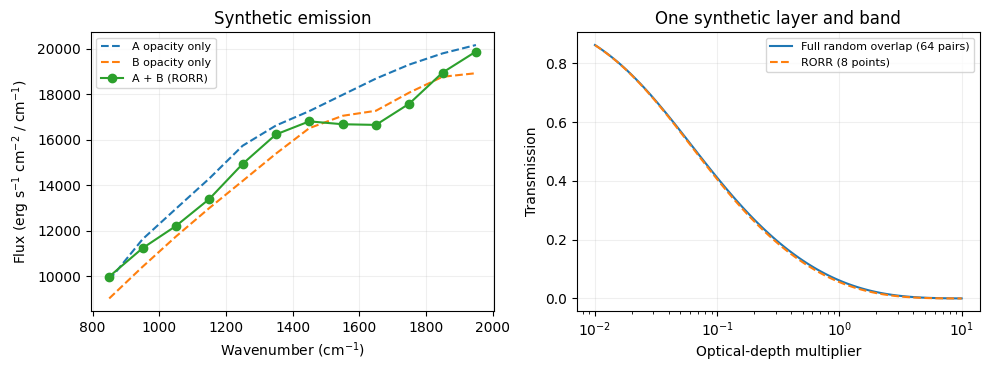

In [4]:
flux_single = [
    art.run_ckd(dtau, temperature, weights, nu_bands)
    for dtau in dtau_species
]
layer, band = -1, 5
pair_tau = (
    dtau_species[0, layer, :, band][:, None]
    + dtau_species[1, layer, :, band][None, :]
)
pair_weights = weights[:, None] * weights[None, :]
path = jnp.logspace(-2.0, 1.0, 100)
transmission_ro = jnp.sum(
    pair_weights[None, :, :] * jnp.exp(-path[:, None, None] * pair_tau),
    axis=(1, 2),
)
transmission_rorr = jnp.sum(
    weights[None, :] * jnp.exp(-path[:, None] * dtau_mix[layer, :, band]),
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for label, flux in zip(("A opacity only", "B opacity only"), flux_single):
    axes[0].plot(nu_bands, flux, "--", label=label)
axes[0].plot(nu_bands, flux_mix, "o-", label="A + B (RORR)")
axes[0].set(xlabel=r"Wavenumber (cm$^{-1}$)",
            ylabel=r"Flux (erg s$^{-1}$ cm$^{-2}$ / cm$^{-1}$)",
            title="Synthetic emission")
axes[1].semilogx(path, transmission_ro, label="Full random overlap (64 pairs)")
axes[1].semilogx(path, transmission_rorr, "--", label="RORR (8 points)")
axes[1].set(xlabel="Optical-depth multiplier", ylabel="Transmission",
            title="One synthetic layer and band")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
print("Maximum absolute transmission compression error in this example:",
      f"{float(jnp.max(jnp.abs(transmission_rorr - transmission_ro))):.3e}")

## Differentiate the full forward model

Keep interpolation, VMR-to-optical-depth conversion, mixing, and
radiative transfer inside the differentiated function. The example
below checks derivatives of the log summed band flux with respect to
log VMR A, log VMR B, and log temperature scale. The mean molecular
weight changes with VMR and contributes to these derivatives.

For fixed sorting order and fixed weights, rebinning is linear in
the input optical depths. JAX differentiates through the selected
order. **The model is not globally smooth**: sorting-order changes
and ties can give different one-sided derivatives. Interpolation
also has slope changes at table grid boundaries; outside a table,
the existing interpolator uses boundary values. Check gradients
away from these boundaries and stay within the table's physical
range when fitting data.

In [5]:
@jax.jit
def log_flux_sum(parameters):
    dtau, temperature, _ = species_optical_depths(parameters[:2], parameters[2])
    mixed = mix_ckd_rorr(dtau, weights)
    flux = art.run_ckd(mixed, temperature, weights, nu_bands)
    return jnp.log(jnp.sum(flux))


parameters = jnp.concatenate((log_vmr, jnp.array([0.0])))
automatic = jax.jit(jax.grad(log_flux_sum))(parameters)
step = 1.e-5
directions = jnp.eye(len(parameters))
finite_difference = jnp.stack([
    (log_flux_sum(parameters + step * direction)
     - log_flux_sum(parameters - step * direction)) / (2.0 * step)
    for direction in directions
])
np.testing.assert_allclose(automatic, finite_difference, rtol=2.e-5, atol=1.e-8)
print("                         autodiff     finite difference")
for label, ad, fd in zip(("log VMR A", "log VMR B", "log T scale"),
                         automatic, finite_difference):
    print(f"{label:>15s}       {float(ad): .8f}       {float(fd): .8f}")

                         autodiff     finite difference
      log VMR A       -0.04015220       -0.04015220
      log VMR B       -0.05325233       -0.05325233
    log T scale        2.36654619        2.36654619


An exactly absent species can be represented by an all-zero optical
depth tensor: the mixer does not take logarithms or divide by the
total abundance. A log-VMR parameterization itself only represents
positive VMRs, so use a linear abundance parameter when testing the
zero boundary. Do not remove a species with an abundance-dependent
Python branch inside a fit. Zero-opacity ties retain the same
piecewise-derivative limitation as other ties.

In [6]:
transparent_second = dtau_species.at[1].set(0.0)
np.testing.assert_allclose(
    mix_ckd_rorr(transparent_second, weights), dtau_species[0],
    rtol=1.e-12, atol=1.e-12,
)
print("A transparent second species leaves the first distribution unchanged.")

A transparent second species leaves the first distribution unchanged.


## Use molecular tables and assess accuracy

Replace the synthetic `opas` with compatible saved tables, for example:

```python
opas = [OpaCKD.from_saved_tables(path) for path in species_table_paths]
validate_ckd_mixture_tables(opas)
weights = opas[0].ckd_info.weights
nu_bands = opas[0].nu_bands
```

Set the molecular masses, abundance profiles, and atmospheric model
for these species. Evaluate each table on the same atmospheric
layers, stack the resulting optical depths, and call the same mixer.
`ArtTransPure.run_ckd` can also consume the mixed tensor and weights;
supply its temperature, mean molecular weight, radius, and gravity
arguments as in the CKD transmission tutorial.

For precomputation, use identical spectral coverage, band edges,
quadrature settings, and band ordering across species. Matching band
centers alone is insufficient. The pressure-broadening assumptions
belong to the individual tables: mixing cannot change them to match
a new background composition.

If a continuum such as CIA is adequately constant within each band,
add its layer optical depth to every mixed point before transfer:

```python
dtau_total = mix_ckd_rorr(dtau_species, weights) + dtau_continuum[:, None, :]
```

Here `dtau_continuum` has shape `(Nlayer, Nband)` and already includes
its abundance and density factors. A continuum varying strongly
within a band needs a more resolved treatment.

Keep these sources of error separate:

- **Overlap assumption:** independent molecular distributions do not
  recover the actual line positions. Compare against a line-by-line
  mixture for representative temperatures, pressures, and compositions.
- **Compression:** compare RORR with full random overlap for a few
  species and vary `Ng`. Mean optical-depth conservation alone is
  insufficient to establish spectral accuracy.
- **Vertical correlation:** using the same mixed probability rank
  across layers assumes correlated absorption ordering. Test cases
  where different species dominate at different heights.

For three or more species, intermediate compression makes the result
depend on the input species order. Choose and retain a fixed order;
sorting species dynamically by abundance introduces additional
changes in the forward model. The finite-difference agreement above
verifies the local derivative of this approximate model, not its
accuracy for a real atmosphere.